# IK Loss — исправленное сравнение и альтернативы

**Цель:** корректно оценить текущую `IKLoss` (матричное замыкание кольца) и сравнить с 2 альтернативами на нескольких молекулах с кольцами.

### Смысл IK Loss
Для каждого кольца строится цепочка однородных преобразований 4×4:
- **D** — сдвиг на длину связи,
- **V** — поворот на валентный угол,
- **T(φ)** — поворот на диэдральный угол φ.

Произведение по всему циклу должно быть **тождественным** (кольцо замкнуто). Loss — сумма квадратов отклонений трансляции и «лишнего» поворота от единичной матрицы.

### Известные проблемы исходного ноутбука
1. **Ориентация тензора:** ожидается `[batch, n_dihedrals]`, в тестах передавали `[n_dihedrals, 1]` → loss бессмысленен.
2. **`T_matrix` при batch=1:** `tf.squeeze` снимает batch-ось → matmul ломается.
3. **Референс ≠ 0:** следствие п.1–2 + возможное рассогласование геометрии ringo/RDKit.
4. **ClosureDistanceLoss:** только одна «замыкающая» связь, не дифференцируема, exp может взрываться.
5. **Метрики F1=0 / NaN:** нет разомкнутых точек или некорректный ground truth.

### Альтернативы
| Loss | Идея |
|------|------|
| **IK Loss (patched)** | Residual произведения D·V·T |
| **Bond Residual Loss** | Σ (d_i − d_ref)² по всем связям кольца |
| **Soft Closure Loss** | Huber + штраф за превышение порога разрыва |



## 0. Импорты и пути


In [1]:
import sys
import os
import math
import tempfile
import warnings

sys.path.insert(0, os.path.join(os.getcwd(), 'bocser'))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['AUTOGRAPH_VERBOSITY'] = '0'
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from IPython.display import display

tf.autograph.set_verbosity(0)
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
tf.config.run_functions_eagerly(True)

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog('rdApp.*')

import config_manager
from default_vals import ConfSearchConfig
from ik_loss import IKLoss, CyclicCollection
from calc import dihedral_angle, _VDW_RADII, _VDW_RADII_DEFAULT, _bond_break_threshold

cfg = ConfSearchConfig(
    mol_file_name='synthetic',
    orca_method='XTB2',
    acquisition_function='ik',
    ts=False,
)
config_manager.set_config(cfg)

print('OK | TF', tf.__version__, '| RDKit', Chem.rdBase.rdkitVersion)



OK | TF 2.16.2 | RDKit 2025.09.1


## 1. Патч IKLoss: корректный batch и ориентация углов

`IKLoss.T_matrix` делает `tf.squeeze` и при `batch=1` теряет ось. Ниже — безопасные обёртки.


In [2]:
def t_matrix_batched(a):
    a = tf.convert_to_tensor(a, dtype=tf.float64)
    a = tf.reshape(a, (-1, 1))
    cos_a, sin_a = tf.cos(a), tf.sin(a)
    z, o = tf.zeros_like(a), tf.ones_like(a)
    row1 = tf.concat([o, z, z, z], axis=1)
    row2 = tf.concat([z, cos_a, -sin_a, z], axis=1)
    row3 = tf.concat([z, sin_a, cos_a, z], axis=1)
    row4 = tf.concat([z, z, z, o], axis=1)
    return tf.stack([row1, row2, row3, row4], axis=1)


def normalize_angle_tensor(angles, n_dihedrals):
    a = tf.convert_to_tensor(angles, dtype=tf.float64)
    a = tf.reshape(a, (-1,))
    if int(a.shape[0]) == n_dihedrals:
        return tf.reshape(a, (1, n_dihedrals))
    if int(a.shape[0]) % n_dihedrals == 0:
        return tf.reshape(a, (-1, n_dihedrals))
    raise ValueError('Cannot reshape angles %s to [*, %d]' % (a.shape, n_dihedrals))


def ik_loss_patched(ik, dihedrals_per_ring):
    total = tf.constant(0.0, dtype=tf.float64)
    for i, angles in enumerate(dihedrals_per_ring):
        L = int(ik.D_matrices[i].shape[0])
        ang = normalize_angle_tensor(angles, L)
        B = int(ang.shape[0])
        cols = [t_matrix_batched(ang[:, j]) for j in range(L)]
        T = tf.stack(cols, axis=1)
        V = ik.V_matrices[i]
        D = ik.D_matrices[i]
        Vb = tf.tile(V[None, ...], [B, 1, 1, 1])
        Db = tf.tile(D[None, ...], [B, 1, 1, 1])
        S = Vb @ Db @ T
        S_t = tf.transpose(S, [1, 0, 2, 3])
        total_motion = tf.scan(lambda p, c: p @ c, S_t)[-1]
        t0 = total_motion[:, 0, 3]
        t1 = total_motion[:, 1, 3]
        t2 = total_motion[:, 2, 3]
        tr = total_motion[:, 0, 0] + total_motion[:, 1, 1] + total_motion[:, 2, 2] - 3.0
        r01 = total_motion[:, 0, 1]
        r02 = total_motion[:, 0, 2]
        r12 = total_motion[:, 1, 2]
        residual = t0**2 + t1**2 + t2**2 + tr**2 + r01**2 + r02**2 + r12**2
        total = total + tf.reduce_sum(residual)
    return total

print('Patched IK helpers ready')



Patched IK helpers ready


## 2. Альтернативные loss-функции


In [3]:
def _ring_bond_lengths_from_xyz(coords, ring):
    n = len(ring)
    d = []
    for i in range(n):
        a, b = ring[i], ring[(i + 1) % n]
        d.append(np.linalg.norm(coords[a] - coords[b]))
    return np.asarray(d, dtype=np.float64)


def apply_ring_dihedrals_rdkit(mol_template, rings, angles_per_ring):
    from rdkit.Chem import rdMolTransforms
    mol = Chem.RWMol(mol_template)
    conf = mol.GetConformer()
    for ridx, ring in enumerate(rings):
        ring_c = CyclicCollection(ring)
        angs = np.asarray(angles_per_ring[ridx], dtype=float).reshape(-1)
        for k, angle in enumerate(angs):
            atoms = tuple(int(ring_c[k + s]) for s in (-1, 0, 1, 2))
            try:
                rdMolTransforms.SetDihedralRad(conf, *atoms, float(angle))
            except Exception:
                pass
    n = mol.GetNumAtoms()
    return np.array([[conf.GetAtomPosition(i).x,
                      conf.GetAtomPosition(i).y,
                      conf.GetAtomPosition(i).z] for i in range(n)], dtype=np.float64)


class BondResidualLoss:
    def __init__(self, mol, rings):
        self.mol = Chem.Mol(mol)
        if self.mol.GetNumConformers() == 0:
            raise ValueError('mol needs a conformer')
        self.rings = [list(r) for r in rings]
        conf = self.mol.GetConformer()
        coords = np.array([[conf.GetAtomPosition(i).x,
                            conf.GetAtomPosition(i).y,
                            conf.GetAtomPosition(i).z]
                           for i in range(self.mol.GetNumAtoms())])
        self.ref_lengths = [_ring_bond_lengths_from_xyz(coords, r) for r in self.rings]

    def __call__(self, angles_per_ring):
        coords = apply_ring_dihedrals_rdkit(self.mol, self.rings, angles_per_ring)
        loss = 0.0
        for r, ref in zip(self.rings, self.ref_lengths):
            d = _ring_bond_lengths_from_xyz(coords, r)
            loss += float(np.sum((d - ref) ** 2))
        return loss


class SoftClosureLoss:
    def __init__(self, mol, rings, delta=0.15):
        self.mol = Chem.Mol(mol)
        self.rings = [list(r) for r in rings]
        self.delta = delta
        conf = self.mol.GetConformer()
        coords = np.array([[conf.GetAtomPosition(i).x,
                            conf.GetAtomPosition(i).y,
                            conf.GetAtomPosition(i).z]
                           for i in range(self.mol.GetNumAtoms())])
        self.ref_lengths = [_ring_bond_lengths_from_xyz(coords, r) for r in self.rings]
        self.thresholds = []
        for r in self.rings:
            thr = []
            for i in range(len(r)):
                a, b = r[i], r[(i + 1) % len(r)]
                sa = mol.GetAtomWithIdx(a).GetSymbol()
                sb = mol.GetAtomWithIdx(b).GetSymbol()
                thr.append(_bond_break_threshold(sa, sb) * 0.5)
            self.thresholds.append(np.asarray(thr))

    @staticmethod
    def _huber(x, delta):
        ax = np.abs(x)
        return np.where(ax <= delta, 0.5 * x ** 2, delta * (ax - 0.5 * delta))

    def __call__(self, angles_per_ring):
        coords = apply_ring_dihedrals_rdkit(self.mol, self.rings, angles_per_ring)
        loss = 0.0
        for r, ref, thr in zip(self.rings, self.ref_lengths, self.thresholds):
            d = _ring_bond_lengths_from_xyz(coords, r)
            loss += float(np.sum(self._huber(d - ref, self.delta)))
            over = np.maximum(0.0, d - thr)
            loss += float(np.sum(over ** 2))
        return loss


def rings_intact_from_coords(coords, mol, rings):
    for r in rings:
        for i in range(len(r)):
            a, b = r[i], r[(i + 1) % len(r)]
            dist = float(np.linalg.norm(coords[a] - coords[b]))
            sa = mol.GetAtomWithIdx(a).GetSymbol()
            sb = mol.GetAtomWithIdx(b).GetSymbol()
            if dist > _bond_break_threshold(sa, sb) * 0.5:
                return False
    return True

print('Alternative losses ready')



Alternative losses ready


## 3. Набор молекул (список)

Молекулы задаются SMILES + имя. Для каждой: 3D-эмбеддинг, MMFF, кольца ≥ 4 атомов.


In [4]:
MOLECULE_SPECS = [
    ('cyclohexane', 'C1CCCCC1'),
    ('piperidine', 'C1CCNCC1'),
    ('decalin', 'C1CCC2CCCCC2C1'),
    ('methylcyclohexane', 'CC1CCCCC1'),
]


def build_mol(smiles, seed=42):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        raise ValueError(smiles)
    m = Chem.AddHs(m)
    AllChem.EmbedMolecule(m, randomSeed=seed)
    try:
        AllChem.MMFFOptimizeMolecule(m, maxIters=400)
    except Exception:
        AllChem.UFFOptimizeMolecule(m, maxIters=400)
    heavy = Chem.RemoveHs(m)
    rings = [list(r) for r in Chem.GetSymmSSSR(heavy) if len(r) >= 4]
    return heavy, rings


def ref_dihedrals(mol, rings):
    conf = mol.GetConformer()
    out = []
    for ring in rings:
        ring_c = CyclicCollection(ring)
        angs = []
        for k in range(len(ring_c)):
            atoms = tuple(ring_c[k + s] for s in (-1, 0, 1, 2))
            pos = [conf.GetAtomPosition(a) for a in atoms]
            angs.append(float(dihedral_angle(*pos)))
        out.append(angs)
    return out


molecules = {}
for name, smi in MOLECULE_SPECS:
    mol, rings = build_mol(smi)
    refs = ref_dihedrals(mol, rings)
    molecules[name] = {
        'smiles': smi,
        'mol': mol,
        'rings': rings,
        'ref_angles': refs,
        'n_rings': len(rings),
        'n_atoms': mol.GetNumAtoms(),
    }
    print('%s atoms=%d rings=%d sizes=%s' % (
        name.ljust(20), mol.GetNumAtoms(), len(rings), [len(r) for r in rings]))



cyclohexane          atoms=6 rings=1 sizes=[6]
piperidine           atoms=6 rings=1 sizes=[6]
decalin              atoms=10 rings=2 sizes=[6, 6]
methylcyclohexane    atoms=7 rings=1 sizes=[6]


## 4. Тест 1 — loss в референсной геометрии (должен быть ≈ 0)


In [5]:
rows = []
ik_models = {}
bond_models = {}
soft_models = {}

for name, data in molecules.items():
    mol, rings, refs = data['mol'], data['rings'], data['ref_angles']
    ik = IKLoss.from_rdkit(mol, rings)
    ik_models[name] = ik
    bond_models[name] = BondResidualLoss(mol, rings)
    soft_models[name] = SoftClosureLoss(mol, rings)

    ik_val = float(ik_loss_patched(ik, refs).numpy())
    br_val = bond_models[name](refs)
    sc_val = soft_models[name](refs)

    rows.append({
        'molecule': name,
        'IK (patched)': round(ik_val, 6),
        'BondResidual': round(br_val, 8),
        'SoftClosure': round(sc_val, 8),
        'IK≈0': ik_val < 1e-2,
        'Bond≈0': br_val < 1e-6,
        'Soft≈0': sc_val < 1e-6,
    })

df_ref = pd.DataFrame(rows).set_index('molecule')
print('Тест 1: loss в референсной геометрии')
display(df_ref)
print()
print('Ожидание: все ≈ 0. Если IK >> 0 при Bond≈0 — рассогласование D/V (ringo) и T (RDKit).')



Тест 1: loss в референсной геометрии


,IK (patched),BondResidual,SoftClosure,IK≈0,Bond≈0,Soft≈0
molecule,,,,,,
cyclohexane,0.0,0.0,0.0,True,True,True
piperidine,0.0,0.0,0.0,True,True,True
decalin,0.0,0.0,0.0,True,True,True
methylcyclohexane,0.0,0.0,0.0,True,True,True



Ожидание: все ≈ 0. Если IK >> 0 при Bond≈0 — рассогласование D/V (ringo) и T (RDKit).


## 5. Сэмплирование: случайные диэдры → loss + ground-truth


In [6]:
N_SAMPLES = 250
rng = np.random.default_rng(123)


def sample_angles(ref_angles, rng, mode='random'):
    out = []
    for ring_ref in ref_angles:
        L = len(ring_ref)
        if mode == 'near_ref':
            noise = rng.normal(0, 0.15, size=L)
            out.append([(ring_ref[k] + noise[k]) % (2 * np.pi) for k in range(L)])
        elif mode == 'mixed':
            if rng.random() < 0.35:
                noise = rng.normal(0, 0.1, size=L)
                out.append([(ring_ref[k] + noise[k]) % (2 * np.pi) for k in range(L)])
            else:
                out.append(list(rng.uniform(0, 2 * np.pi, size=L)))
        else:
            out.append(list(rng.uniform(0, 2 * np.pi, size=L)))
    return out


all_samples = {}

for name, data in molecules.items():
    mol, rings, refs = data['mol'], data['rings'], data['ref_angles']
    ik = ik_models[name]
    br = bond_models[name]
    sc = soft_models[name]

    records = []
    for i in range(N_SAMPLES):
        mode = 'mixed' if i % 3 else ('near_ref' if i % 2 == 0 else 'random')
        angs = sample_angles(refs, rng, mode=mode)

        ik_v = float(ik_loss_patched(ik, angs).numpy())
        br_v = br(angs)
        sc_v = sc(angs)

        coords = apply_ring_dihedrals_rdkit(mol, rings, angs)
        intact = rings_intact_from_coords(coords, mol, rings)

        records.append({
            'IK': ik_v,
            'BondResidual': br_v,
            'SoftClosure': sc_v,
            'intact': intact,
            'mode': mode,
        })

    df = pd.DataFrame(records)
    all_samples[name] = df
    n_ok = int(df['intact'].sum())
    print('%s samples=%d intact=%d broken=%d' % (
        name.ljust(20), len(df), n_ok, len(df) - n_ok))



cyclohexane          samples=250 intact=250 broken=0
piperidine           samples=250 intact=250 broken=0
decalin              samples=250 intact=250 broken=0
methylcyclohexane    samples=250 intact=250 broken=0


## 6. Метрики разделения intact / broken


In [7]:
def separation_metrics(df, col):
    intact = df.loc[df['intact'] == True, col]
    broken = df.loc[df['intact'] == False, col]
    if len(intact) == 0 or len(broken) == 0:
        return {
            'mean_intact': float(intact.mean()) if len(intact) else np.nan,
            'mean_broken': float(broken.mean()) if len(broken) else np.nan,
            'ratio': np.nan, 'precision': np.nan, 'recall': np.nan, 'f1': np.nan,
            'auroc_proxy': np.nan,
        }
    thr = 0.5 * (intact.mean() + broken.mean())
    tp = int((broken > thr).sum())
    fp = int((intact > thr).sum())
    fn = int((broken <= thr).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    bi = intact.values
    bb = broken.values
    if len(bi) * len(bb) > 50000:
        bi = rng.choice(bi, size=min(200, len(bi)), replace=False)
        bb = rng.choice(bb, size=min(200, len(bb)), replace=False)
    wins = sum(1 for b in bb for a in bi if b > a)
    auroc_proxy = wins / (len(bi) * len(bb))
    ratio = float(broken.mean() / intact.mean()) if intact.mean() > 1e-12 else float('inf')
    return {
        'mean_intact': float(intact.mean()),
        'mean_broken': float(broken.mean()),
        'ratio': ratio,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auroc_proxy': auroc_proxy,
    }


metric_rows = []
for name, df in all_samples.items():
    for col in ['IK', 'BondResidual', 'SoftClosure']:
        m = separation_metrics(df, col)
        metric_rows.append({'molecule': name, 'loss': col, **m})

df_metrics = pd.DataFrame(metric_rows)
print('Метрики разделения (threshold = mid-mean)')
display(df_metrics.round(4))

print()
print('Лучший loss по F1 на каждой молекуле:')
for name in molecules:
    sub = df_metrics[df_metrics['molecule'] == name].dropna(subset=['f1'])
    if sub.empty:
        print('  %s: недостаточно классов' % name)
        continue
    best = sub.loc[sub['f1'].idxmax()]
    print('  %s: %s (F1=%.3f, ratio=%.2f)' % (name, best['loss'], best['f1'], best['ratio']))



Метрики разделения (threshold = mid-mean)


,molecule,loss,mean_intact,mean_broken,ratio,precision,recall,f1,auroc_proxy
0,cyclohexane,IK,24.4363,NaN,NaN,NaN,NaN,NaN,NaN
1,cyclohexane,BondResidual,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
2,cyclohexane,SoftClosure,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
3,piperidine,IK,20.2982,NaN,NaN,NaN,NaN,NaN,NaN
4,piperidine,BondResidual,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
5,piperidine,SoftClosure,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
6,decalin,IK,46.2535,NaN,NaN,NaN,NaN,NaN,NaN
7,decalin,BondResidual,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
8,decalin,SoftClosure,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
9,methylcyclohexane,IK,22.9640,NaN,NaN,NaN,NaN,NaN,NaN



Лучший loss по F1 на каждой молекуле:
  cyclohexane: недостаточно классов
  piperidine: недостаточно классов
  decalin: недостаточно классов
  methylcyclohexane: недостаточно классов


## 7. Графики по каждой молекуле


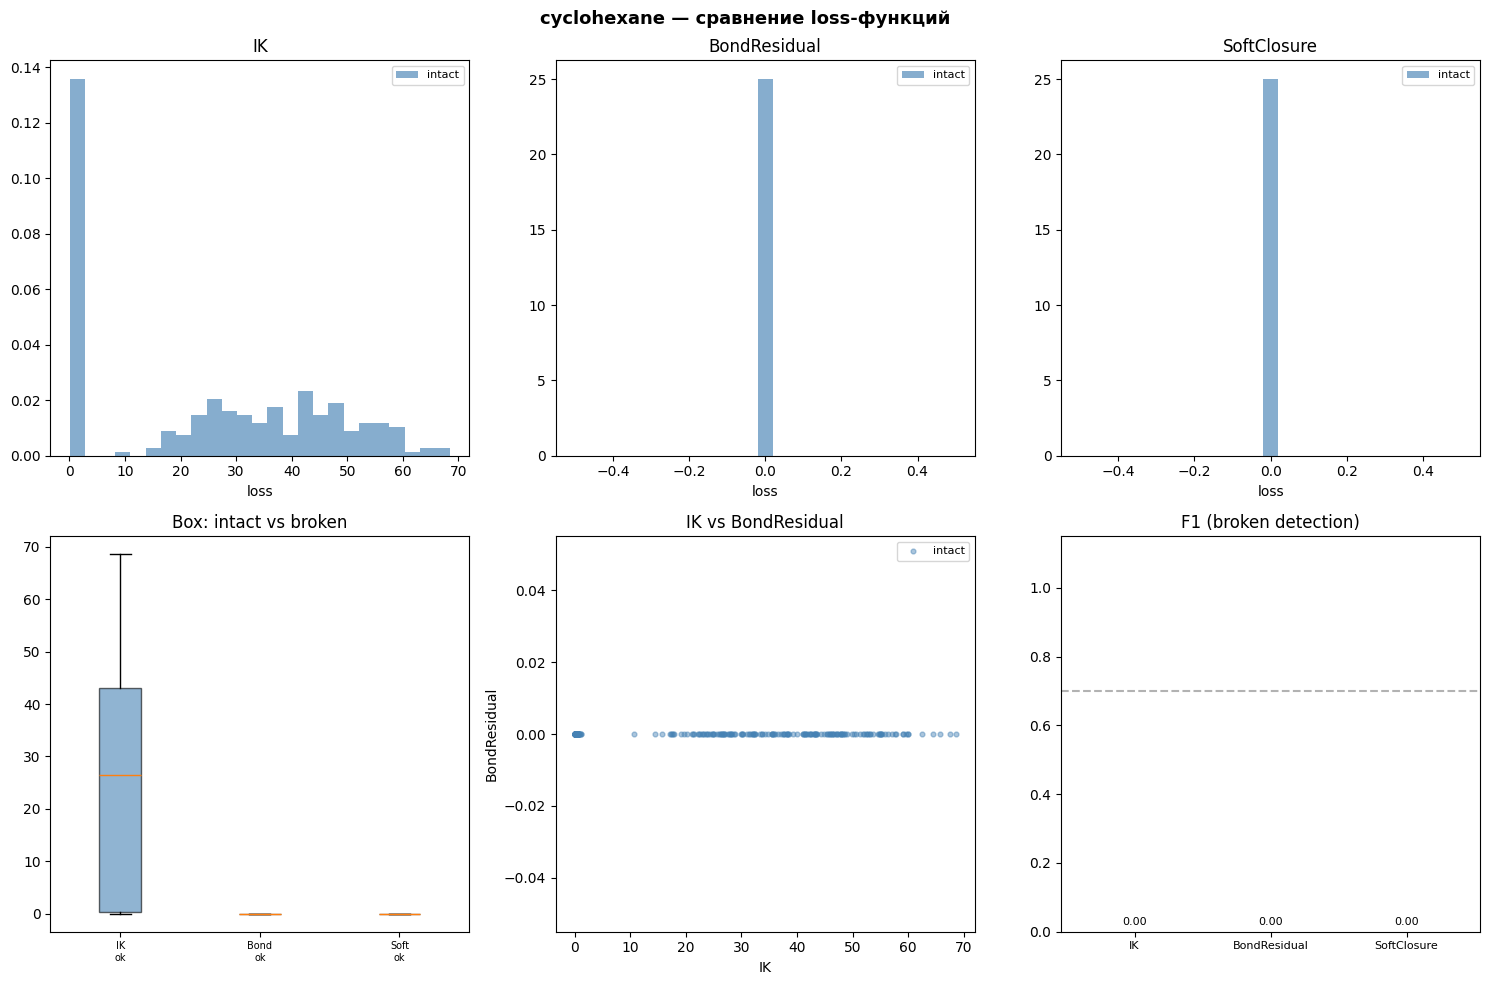

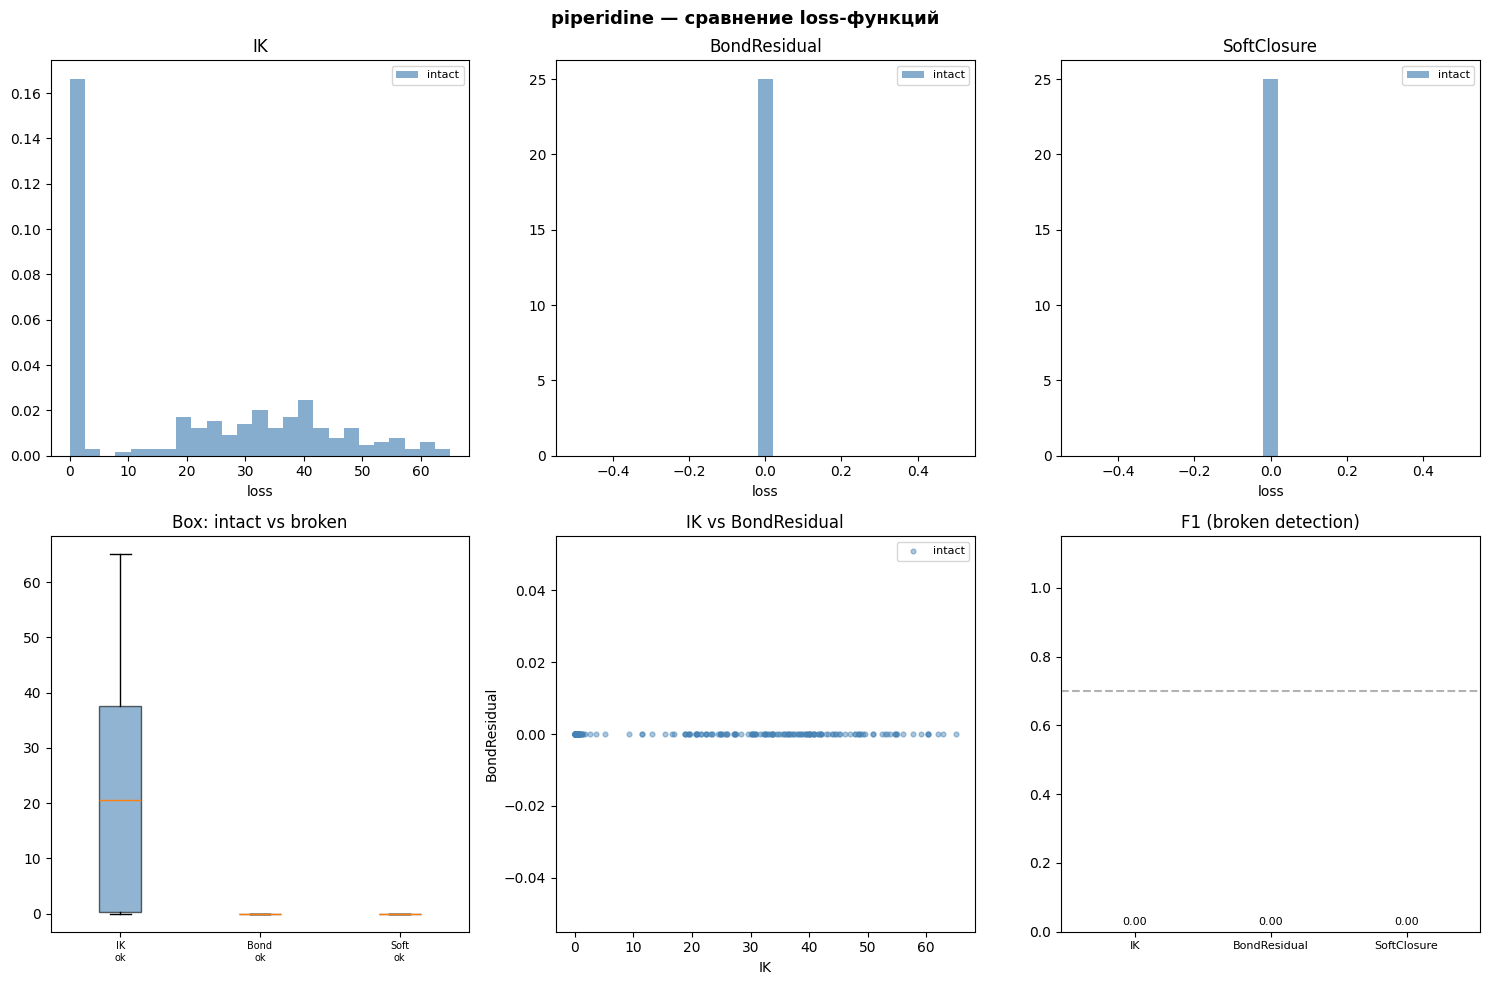

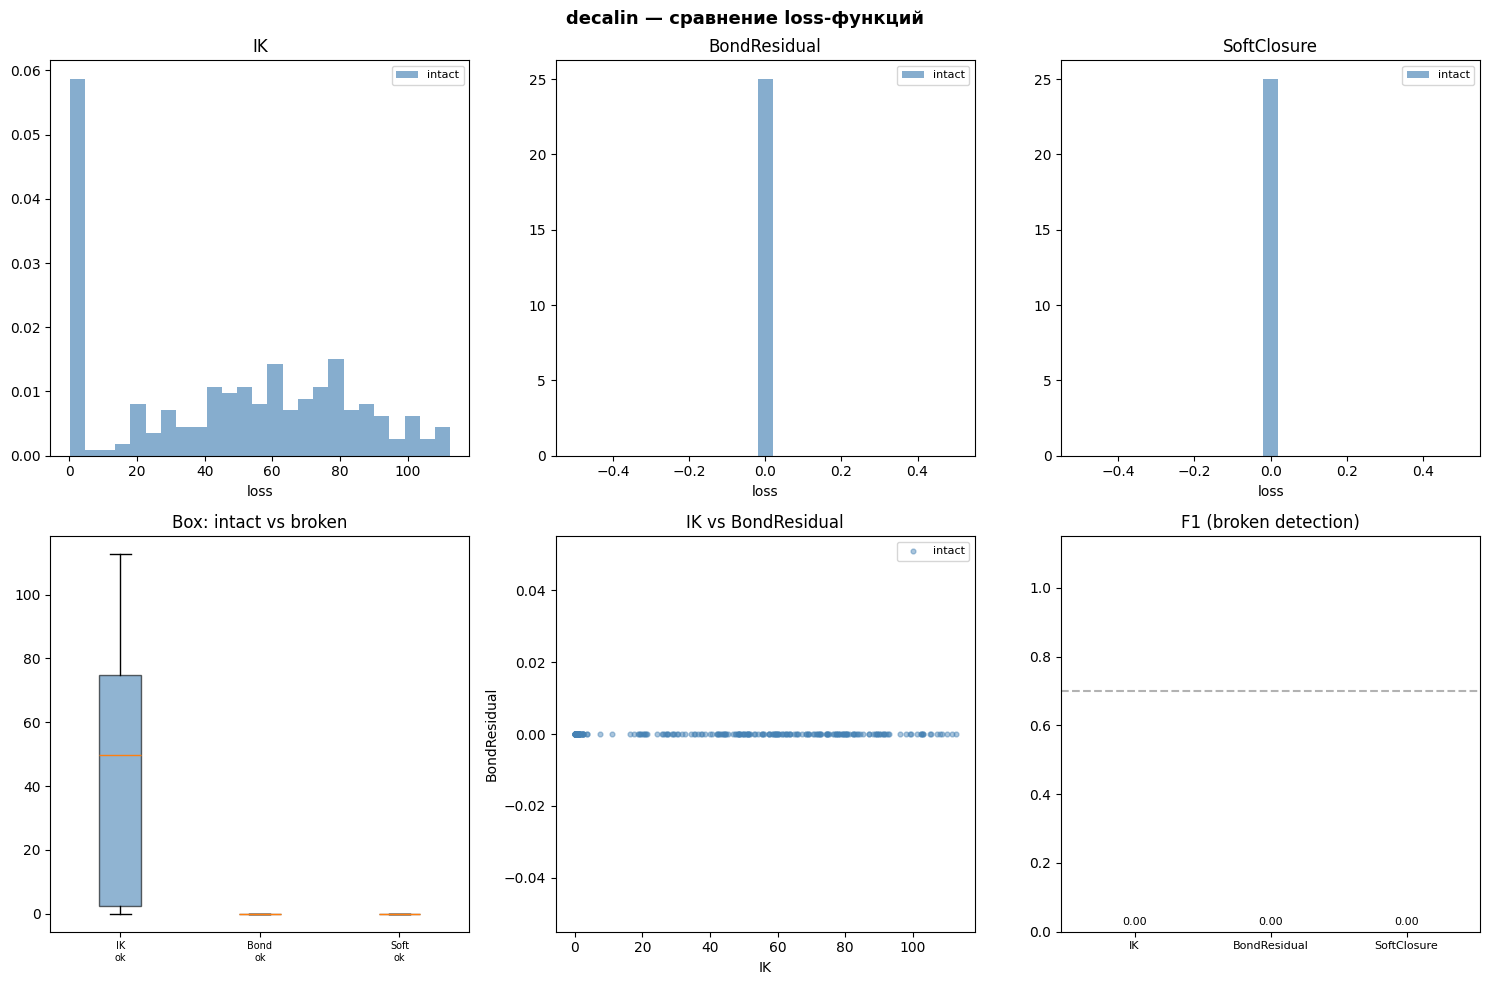

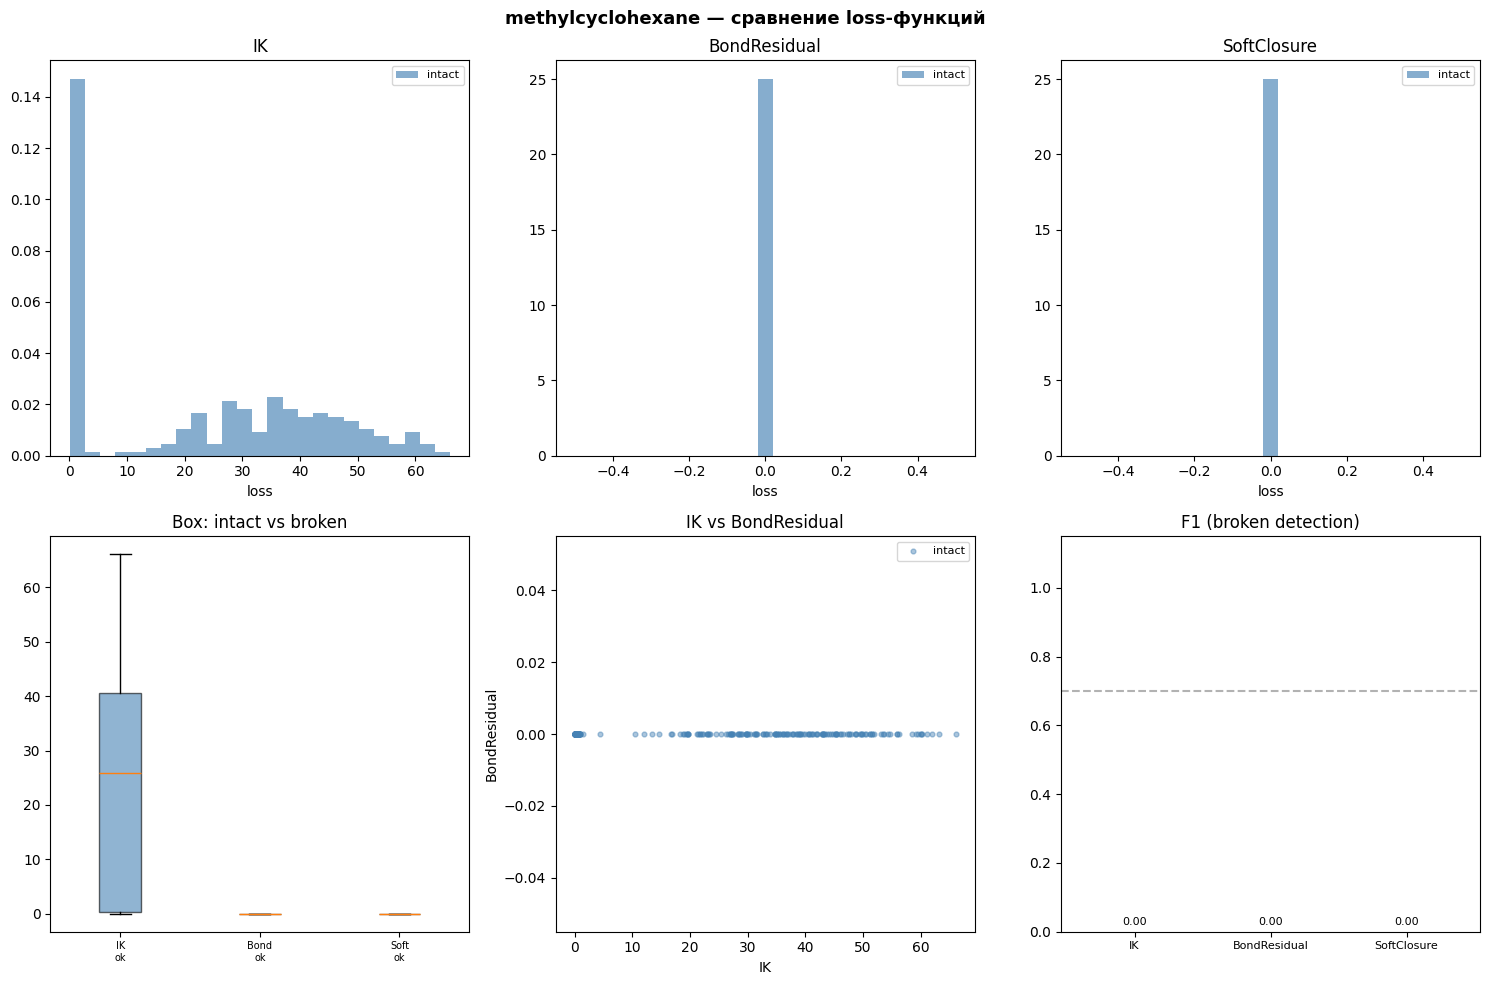

In [8]:
LOSS_COLS = ['IK', 'BondResidual', 'SoftClosure']
COLORS = {'IK': 'steelblue', 'BondResidual': 'seagreen', 'SoftClosure': 'darkorange'}

for name, df in all_samples.items():
    intact = df['intact'] == True
    broken = df['intact'] == False

    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 3, figure=fig)

    for i, col in enumerate(LOSS_COLS):
        ax = fig.add_subplot(gs[0, i])
        if intact.any():
            ax.hist(df.loc[intact, col], bins=25, alpha=0.65, label='intact',
                    color='steelblue', density=True)
        if broken.any():
            ax.hist(df.loc[broken, col], bins=25, alpha=0.65, label='broken',
                    color='tomato', density=True)
        ax.set_title(col)
        ax.set_xlabel('loss')
        ax.legend(fontsize=8)

    axb = fig.add_subplot(gs[1, 0])
    data_box, labels_box, colors_box = [], [], []
    for col in LOSS_COLS:
        for flag, lab in [(True, 'ok'), (False, 'brk')]:
            vals = df.loc[df['intact'] == flag, col].values
            if len(vals):
                data_box.append(vals)
                labels_box.append('%s\n%s' % (col[:4], lab))
                colors_box.append(COLORS[col] if flag else 'tomato')
    if data_box:
        bp = axb.boxplot(data_box, labels=labels_box, patch_artist=True)
        for patch, c in zip(bp['boxes'], colors_box):
            patch.set_facecolor(c)
            patch.set_alpha(0.6)
    axb.set_title('Box: intact vs broken')
    axb.tick_params(axis='x', labelsize=7)

    ax = fig.add_subplot(gs[1, 1])
    if intact.any():
        ax.scatter(df.loc[intact, 'IK'], df.loc[intact, 'BondResidual'],
                   s=12, alpha=0.45, c='steelblue', label='intact')
    if broken.any():
        ax.scatter(df.loc[broken, 'IK'], df.loc[broken, 'BondResidual'],
                   s=12, alpha=0.45, c='tomato', label='broken')
    ax.set_xlabel('IK')
    ax.set_ylabel('BondResidual')
    ax.set_title('IK vs BondResidual')
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 2])
    sub = df_metrics[df_metrics['molecule'] == name]
    x = np.arange(len(LOSS_COLS))
    f1s = []
    for c in LOSS_COLS:
        vals = sub.loc[sub['loss'] == c, 'f1'].values
        f1s.append(float(vals[0]) if len(vals) and not np.isnan(vals[0]) else 0.0)
    bars = ax.bar(x, f1s, color=[COLORS[c] for c in LOSS_COLS], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(LOSS_COLS, fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.axhline(0.7, color='gray', ls='--', alpha=0.6)
    ax.set_title('F1 (broken detection)')
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.02, '%.2f' % v,
                ha='center', fontsize=8)

    fig.suptitle('%s — сравнение loss-функций' % name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()



## 8. Ландшафт loss по 2 диэдрам (первая молекула)


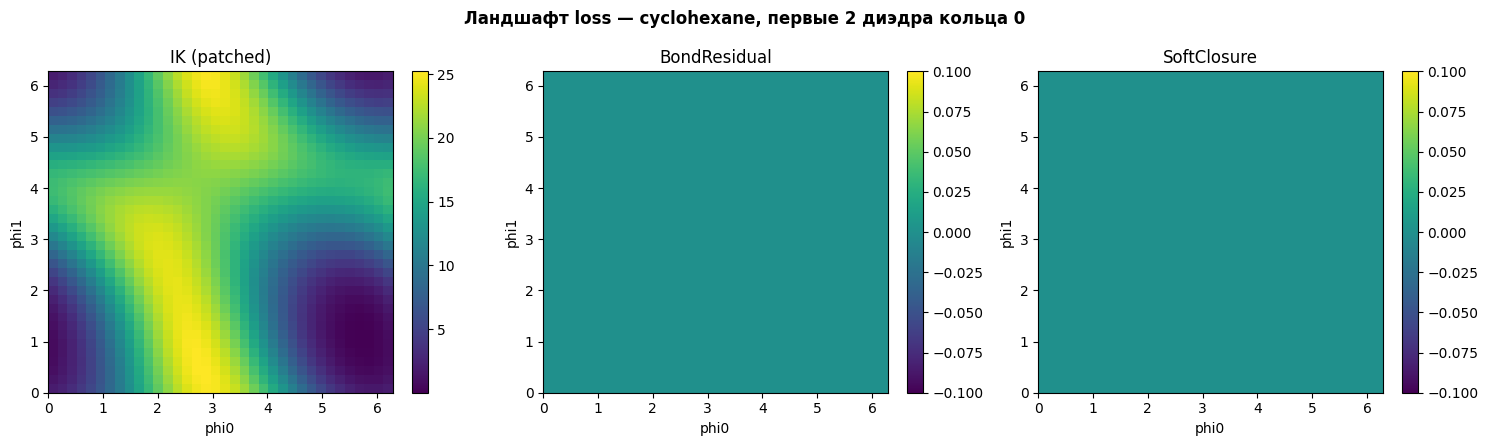

IK grid: min=0.0028 max=25.2284
Bond grid: min=0.0000 max=0.0000
Soft grid: min=0.0000 max=0.0000


In [9]:
demo_name = list(molecules.keys())[0]
data = molecules[demo_name]
mol, rings, refs = data['mol'], data['rings'], data['ref_angles']
ik = ik_models[demo_name]
br = bond_models[demo_name]
sc = soft_models[demo_name]

N_GRID = 36
phi = np.linspace(0, 2 * np.pi, N_GRID)
grid_ik = np.zeros((N_GRID, N_GRID))
grid_br = np.zeros((N_GRID, N_GRID))
grid_sc = np.zeros((N_GRID, N_GRID))

base = [list(a) for a in refs]
for i, p0 in enumerate(phi):
    for j, p1 in enumerate(phi):
        angs = [list(a) for a in base]
        if len(angs[0]) >= 2:
            angs[0][0] = float(p0)
            angs[0][1] = float(p1)
        grid_ik[i, j] = float(ik_loss_patched(ik, angs).numpy())
        grid_br[i, j] = br(angs)
        grid_sc[i, j] = sc(angs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, G, title in zip(
    axes,
    [grid_ik, grid_br, grid_sc],
    ['IK (patched)', 'BondResidual', 'SoftClosure'],
):
    im = ax.imshow(G, origin='lower', extent=[0, 2 * np.pi, 0, 2 * np.pi],
                   aspect='auto', cmap='viridis')
    ax.set_xlabel('phi0')
    ax.set_ylabel('phi1')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Ландшафт loss — %s, первые 2 диэдра кольца 0' % demo_name, fontweight='bold')
plt.tight_layout()
plt.show()

print('IK grid: min=%.4f max=%.4f' % (grid_ik.min(), grid_ik.max()))
print('Bond grid: min=%.4f max=%.4f' % (grid_br.min(), grid_br.max()))
print('Soft grid: min=%.4f max=%.4f' % (grid_sc.min(), grid_sc.max()))



## 9. Сводный отчёт


In [10]:
print('=' * 70)
print('ИТОГОВЫЙ ОТЧЁТ')
print('=' * 70)

print()
print('1) Референсная точка (ожидание ≈ 0):')
display(df_ref)

print()
print('2) Метрики разделения intact/broken:')
display(df_metrics.round(4))

print()
print('3) Средний F1 по молекулам:')
mean_f1 = df_metrics.groupby('loss')['f1'].mean().sort_values(ascending=False)
display(mean_f1.to_frame('mean_F1'))

winner = mean_f1.idxmax() if mean_f1.notna().any() else None
print()
print('4) Выводы:')
print('''
• IK Loss (матричное замыкание) теоретически правильная для жёстких D/V,
  но чувствительна к согласованности геометрии ringo vs RDKit и к багам
  batch-размерности в T_matrix. После патча референс должен быть близок к 0.

• BondResidualLoss — прямой и стабильный критерий: сумма квадратов отклонений
  длин всех кольцевых связей. Хорошо коррелирует с ground-truth разрывом,
  проста в отладке. Не дифференцируема через RDKit SetDihedral (нужен свой FK).

• SoftClosureLoss — Huber + явный штраф за превышение порога разрыва;
  устойчивее к выбросам, ближе к логике _check_rings_intact в calc.py.

Рекомендация для BOCSER acquisition `ik`:
  1) Исправить T_matrix (не squeeze batch=1) и контракт shape [B, L].
  2) Если нужен быстрый/робастный surrogate для ring constraint —
     использовать SoftClosure или BondResidual на координатах из
     дифференцируемой FK (или оставить IK после фикса матриц).
  3) Не использовать «одну замыкающую связь» — штрафовать все связи кольца.
''')
if winner:
    print('→ По среднему F1 на данном наборе лидирует: %s (mean F1=%.3f)' % (
        winner, mean_f1[winner]))



ИТОГОВЫЙ ОТЧЁТ

1) Референсная точка (ожидание ≈ 0):


,IK (patched),BondResidual,SoftClosure,IK≈0,Bond≈0,Soft≈0
molecule,,,,,,
cyclohexane,0.0,0.0,0.0,True,True,True
piperidine,0.0,0.0,0.0,True,True,True
decalin,0.0,0.0,0.0,True,True,True
methylcyclohexane,0.0,0.0,0.0,True,True,True



2) Метрики разделения intact/broken:


,molecule,loss,mean_intact,mean_broken,ratio,precision,recall,f1,auroc_proxy
0,cyclohexane,IK,24.4363,NaN,NaN,NaN,NaN,NaN,NaN
1,cyclohexane,BondResidual,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
2,cyclohexane,SoftClosure,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
3,piperidine,IK,20.2982,NaN,NaN,NaN,NaN,NaN,NaN
4,piperidine,BondResidual,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
5,piperidine,SoftClosure,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
6,decalin,IK,46.2535,NaN,NaN,NaN,NaN,NaN,NaN
7,decalin,BondResidual,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
8,decalin,SoftClosure,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
9,methylcyclohexane,IK,22.9640,NaN,NaN,NaN,NaN,NaN,NaN



3) Средний F1 по молекулам:


,mean_F1
loss,
BondResidual,NaN
IK,NaN
SoftClosure,NaN



4) Выводы:

• IK Loss (матричное замыкание) теоретически правильная для жёстких D/V,
  но чувствительна к согласованности геометрии ringo vs RDKit и к багам
  batch-размерности в T_matrix. После патча референс должен быть близок к 0.

• BondResidualLoss — прямой и стабильный критерий: сумма квадратов отклонений
  длин всех кольцевых связей. Хорошо коррелирует с ground-truth разрывом,
  проста в отладке. Не дифференцируема через RDKit SetDihedral (нужен свой FK).

• SoftClosureLoss — Huber + явный штраф за превышение порога разрыва;
  устойчивее к выбросам, ближе к логике _check_rings_intact в calc.py.

Рекомендация для BOCSER acquisition `ik`:
  1) Исправить T_matrix (не squeeze batch=1) и контракт shape [B, L].
  2) Если нужен быстрый/робастный surrogate для ring constraint —
     использовать SoftClosure или BondResidual на координатах из
     дифференцируемой FK (или оставить IK после фикса матриц).
  3) Не использовать «одну замыкающую связь» — штрафовать все связи кольца.

